In [1]:
seed = 100

### Librerías y carga previa

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_validate, cross_val_predict, StratifiedKFold
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd
from scipy import stats
import numpy as np

df = pd.read_csv("data/dataset.csv")

# Definimos variables descriptoras (X) y objetivo (y)
features = ['HORA_SIN', 'HORA_COS', 'PRECIP_MOMENTO', 'TEMP_ESTIMADA', 'Racha (km/h)']
X = df[features]
y = df['GRAVEDAD']

### MODELO SUPERVISADO: RANDOM FOREST

In [3]:
# Creamos las variables dummy
df_dummies = pd.get_dummies(df[['COMPAÑIA', 'ORIGEN_ICAO', 'DESTINO_ICAO']], drop_first=False)

# Unimos las dummies con nuestras variables numéricas climáticas
X_s = pd.concat([df[features], df_dummies], axis=1)

# RANDOM FOREST
X_train, X_test, y_train, y_test = train_test_split(X_s, y, test_size=0.2, random_state=seed, stratify=y)

rf_model = RandomForestClassifier(n_estimators=75, random_state=seed, class_weight='balanced_subsample')

# Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

y_pred_cv = cross_val_predict(
    estimator=rf_model, 
    X=X_train, 
    y=y_train, 
    cv=5,
    n_jobs=-1
)

print("\n--- REPORTE DEL RANDOM FOREST (5-Folds) ---")
print(classification_report(y_train, y_pred_cv))


--- REPORTE DEL RANDOM FOREST (5-Folds) ---
              precision    recall  f1-score   support

           0       0.86      0.93      0.89     12530
           1       0.73      0.70      0.72      4873
           2       0.76      0.55      0.64      1762
           3       0.80      0.56      0.66       698
           4       0.92      0.57      0.71        40

    accuracy                           0.82     19903
   macro avg       0.82      0.66      0.72     19903
weighted avg       0.82      0.82      0.82     19903



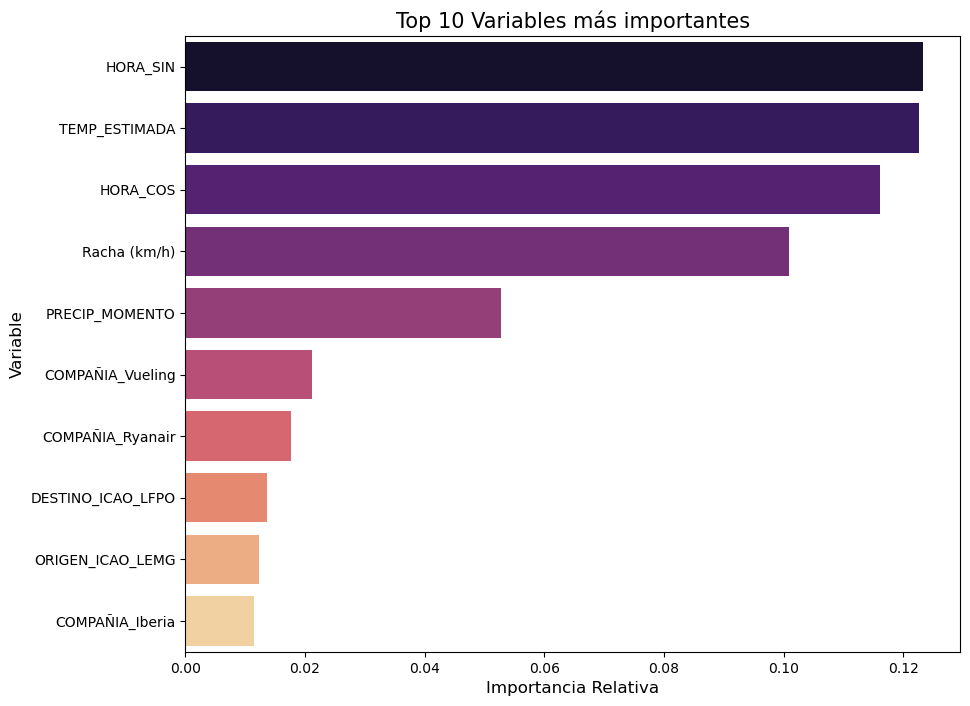

In [4]:
rf_model.fit(X_train, y_train)

# Top 10 Variables con más importancia
importancias = pd.DataFrame({
    'Variable': X_train.columns, 
    'Importancia': rf_model.feature_importances_
})
importancias = importancias.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    hue='Variable',
    legend=False,
    data=importancias, 
    palette='magma'
)

plt.title('Top 10 Variables más importantes', fontsize=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.show()

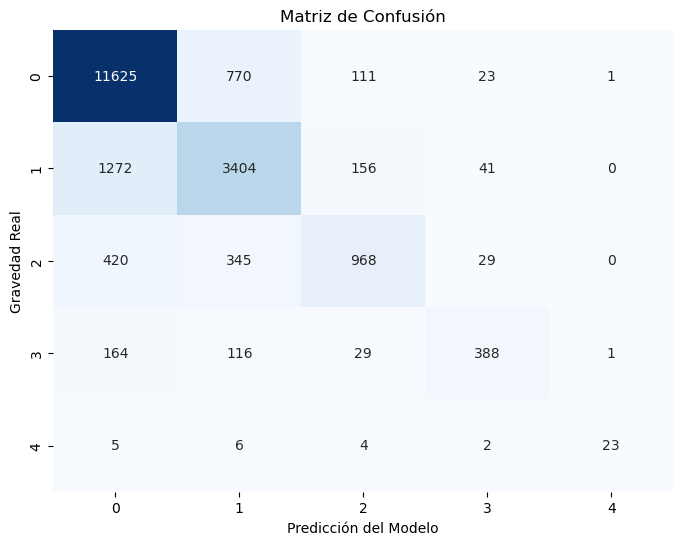

In [5]:
# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_train, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Gravedad Real')
plt.show()

### MODELO NO SUPERVISADO: K-MEANS

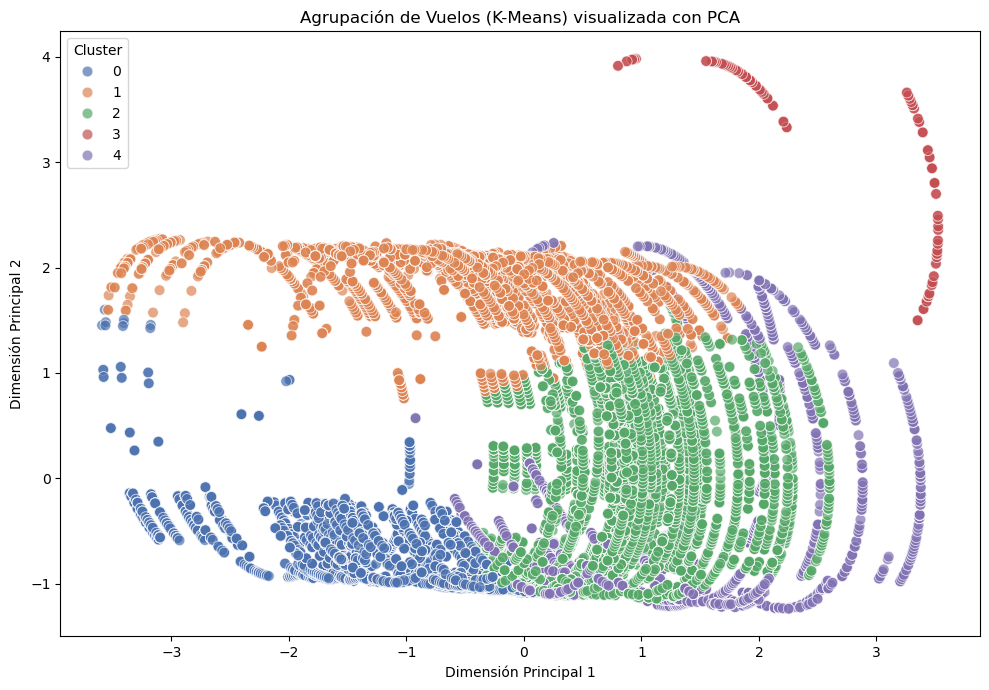

In [6]:
# K-MEANS
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Buscamos 5 clusters
kmeans = KMeans(n_clusters=5, random_state=seed, n_init=10)
df['CLUSTER'] = kmeans.fit_predict(X_scaled) 

# Visualización con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['Componente 1', 'Componente 2'])
df_pca['CLUSTER'] = df['CLUSTER']

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente 1', 
    y='Componente 2', 
    hue='CLUSTER', 
    data=df_pca, 
    palette='deep', 
    s=60, 
    alpha=0.7
)
plt.title('Agrupación de Vuelos (K-Means) visualizada con PCA')
plt.xlabel('Dimensión Principal 1')
plt.ylabel('Dimensión Principal 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

Una vez vistos cómo el modelo ha intentado agrupar los clusters vamos a intentar ver si guardan relación con la gravedad.

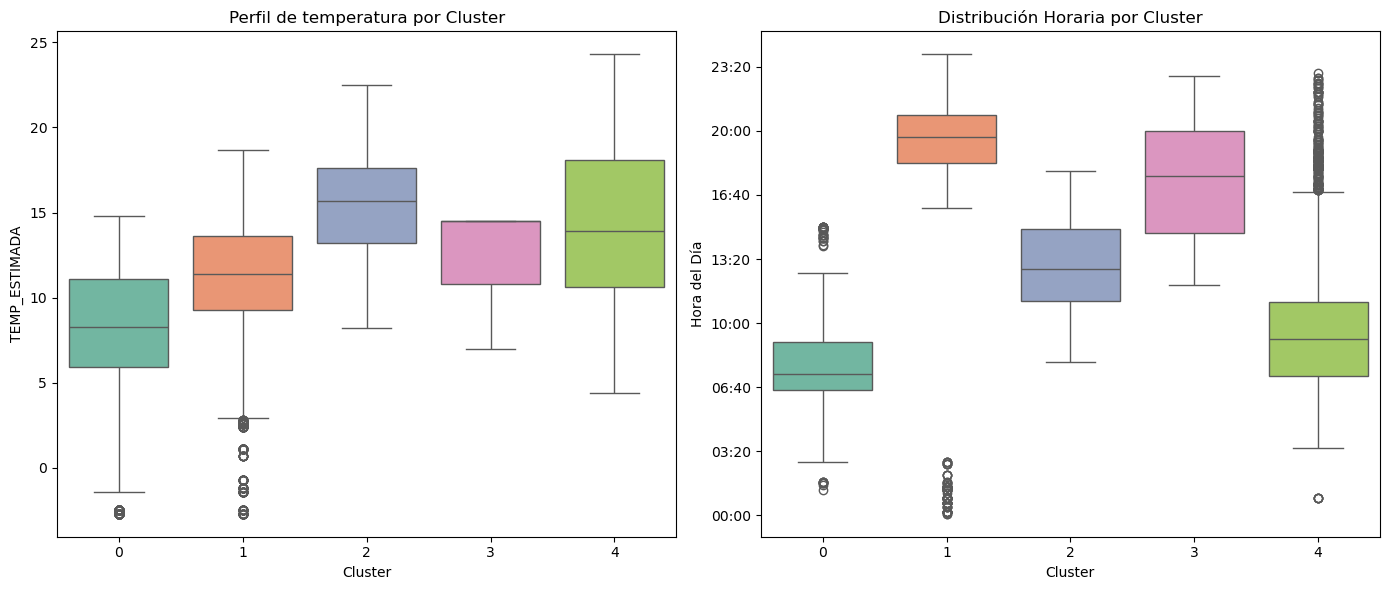

Gravedad promedio por Cluster:
CLUSTER
0    0.341411
1    0.616281
2    0.573811
3    2.290909
4    0.662897
Name: GRAVEDAD, dtype: float64


In [7]:
def minutes_to_time(x, pos):
    """Convierte minutos del día a formato HH:MM"""
    hours = int(x // 60)
    minutes = int(x % 60)
    return f"{hours:02d}:{minutes:02d}"

# Boxplots
plt.figure(figsize=(14, 6))

# Viento por Cluster
plt.subplot(1, 2, 1)
sns.boxplot(
    x='CLUSTER', 
    y='TEMP_ESTIMADA', 
    hue='CLUSTER',
    data=df, 
    palette="Set2",
    legend=False
)
plt.title('Perfil de temperatura por Cluster')
plt.xlabel('Cluster')
plt.ylabel('TEMP_ESTIMADA')

# Distribución Horaria por Cluster
ax2 = plt.subplot(1, 2, 2)
sns.boxplot(
    x='CLUSTER', 
    y='MINUTOS_DIA', 
    hue='CLUSTER',
    data=df, 
    palette="Set2",
    legend=False
)
plt.title('Distribución Horaria por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Hora del Día')

ax2.yaxis.set_major_formatter(FuncFormatter(minutes_to_time))

plt.tight_layout()
plt.show()

# Miramos la gravedad media por cada cluster encontrado
analisis_clusters = df.groupby('CLUSTER')['GRAVEDAD'].mean()
print("Gravedad promedio por Cluster:")
print(analisis_clusters)

### Contraste de Hipótesis.
En el random forest hemos visto que, entre las variables meteorológicas que explican la gravedad del vuelo, la precipitación era la que menos la explicaba, por ello, la hipótesis que lanzo es la siguiente.

H0: No hay diferencia en retrasos entre vuelos con y sin lluvia

H1: Los vuelos con lluvia tienen retrasos diferentes

Tomaremos como vuelos sin lluvia aquellos vuelos con una precipitación menos a 0.5mm ya que este valor es muy bajo de precipitaciones.

In [8]:
# Definimos los grupos y la hipótesis
umbral_lluvia = 0.5  # mm
grupo_lluvia = df[df['PRECIP_MOMENTO'] >= umbral_lluvia]['RETRASO_MIN']
grupo_seco = df[df['PRECIP_MOMENTO'] < umbral_lluvia]['RETRASO_MIN']

print("CONTRASTE DE HIPÓTESIS: ¿La lluvia afecta los retrasos?")
print(f"\nH0: No hay diferencia en retrasos entre vuelos con y sin lluvia")
print(f"H1: Los vuelos con lluvia tienen retrasos diferentes\n")
print(f"Umbral de lluvia: {umbral_lluvia} mm")
print(f"Muestras: Con lluvia {len(grupo_lluvia)}, Sin lluvia {len(grupo_seco)}")


print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
print(f"Con lluvia:")
print(f"  Media: {grupo_lluvia.mean():.2f} min | Mediana: {grupo_lluvia.median():.2f} min")
print(f"  Desv. Est: {grupo_lluvia.std():.2f} min")
print(f"\nSin lluvia:")
print(f"  Media: {grupo_seco.mean():.2f} min | Mediana: {grupo_seco.median():.2f} min")
print(f"  Desv. Est: {grupo_seco.std():.2f} min")

CONTRASTE DE HIPÓTESIS: ¿La lluvia afecta los retrasos?

H0: No hay diferencia en retrasos entre vuelos con y sin lluvia
H1: Los vuelos con lluvia tienen retrasos diferentes

Umbral de lluvia: 0.5 mm
Muestras: Con lluvia 2768, Sin lluvia 22111

--- ESTADÍSTICAS DESCRIPTIVAS ---
Con lluvia:
  Media: 36.20 min | Mediana: 18.00 min
  Desv. Est: 71.38 min

Sin lluvia:
  Media: 23.14 min | Mediana: 14.00 min
  Desv. Est: 46.15 min


Antes de realizar alguna prueba para ver el contraste de hipótesis debemos ver la naturaleza de los datos, su normalidad y sus varianzas.

In [9]:
n_sample = min(5000, len(grupo_lluvia), len(grupo_seco))
_, p_shapiro_lluvia = stats.shapiro(grupo_lluvia.sample(n_sample, random_state=42))
_, p_shapiro_seco = stats.shapiro(grupo_seco.sample(n_sample, random_state=42))

print(f"\n--- PRUEBA DE NORMALIDAD (Shapiro-Wilk, n={n_sample}) ---")
print(f"Con lluvia (p-value): {p_shapiro_lluvia:.4f}")
print(f"Sin lluvia (p-value): {p_shapiro_seco:.4f}")

if p_shapiro_lluvia < 0.05 or p_shapiro_seco < 0.05:
    print("Los datos NO son normales (p < 0.05)")
else:
    print("Los datos parecen normales (p > 0.05)")

_, p_levene = stats.levene(grupo_lluvia, grupo_seco)
print(f"\n--- PRUEBA DE HOMOCEDASTICIDAD (Levene) ---")
print(f"p-value: {p_levene:.4f}")
if p_levene < 0.05:
    print("Las varianzas NO son iguales (p < 0.05)")
else:
    print("Las varianzas son similares (p > 0.05)")


--- PRUEBA DE NORMALIDAD (Shapiro-Wilk, n=2768) ---
Con lluvia (p-value): 0.0000
Sin lluvia (p-value): 0.0000
Los datos NO son normales (p < 0.05)

--- PRUEBA DE HOMOCEDASTICIDAD (Levene) ---
p-value: 0.0000
Las varianzas NO son iguales (p < 0.05)


Una vez hemos visto que los datos no son normales ni sus varianzas son iguales ya podemos saber qué prueba usar.

El cuatrimestre pasado, en la asignatura de "Análisis estadistico", en estos casos, con muestras mayores de 30 datos, siguiendo el teorema central del límite nos decían de utilizar un estadístico de contraste con la Prueba z o la "t de Welch"

In [10]:
t_stat, p_val = stats.ttest_ind(grupo_lluvia, grupo_seco, equal_var=False)

print(f"Estadístico t: {t_stat:.2f}")
print(f"p-value: {p_val:.10f}")
print(f"Nivel de significancia (α): 0.05")

if p_val < 0.05:
    print("\nRECHAZAMOS H0 (p < 0.05)")
    print("   → HAY evidencia significativa de que la media de retrasos es diferente.")
else:
    print("\nNO RECHAZAMOS H0 (p >= 0.05)")
    print("   → NO hay evidencia suficiente de diferencia en las medias.")

Estadístico t: 9.38
p-value: 0.0000000000
Nivel de significancia (α): 0.05

RECHAZAMOS H0 (p < 0.05)
   → HAY evidencia significativa de que la media de retrasos es diferente.


Después del contraste de hipótesis con números, el cerebro humano interpreta mejor los datos visualmente, con que dejo aquí algunas gráficas para ver las diferencias.

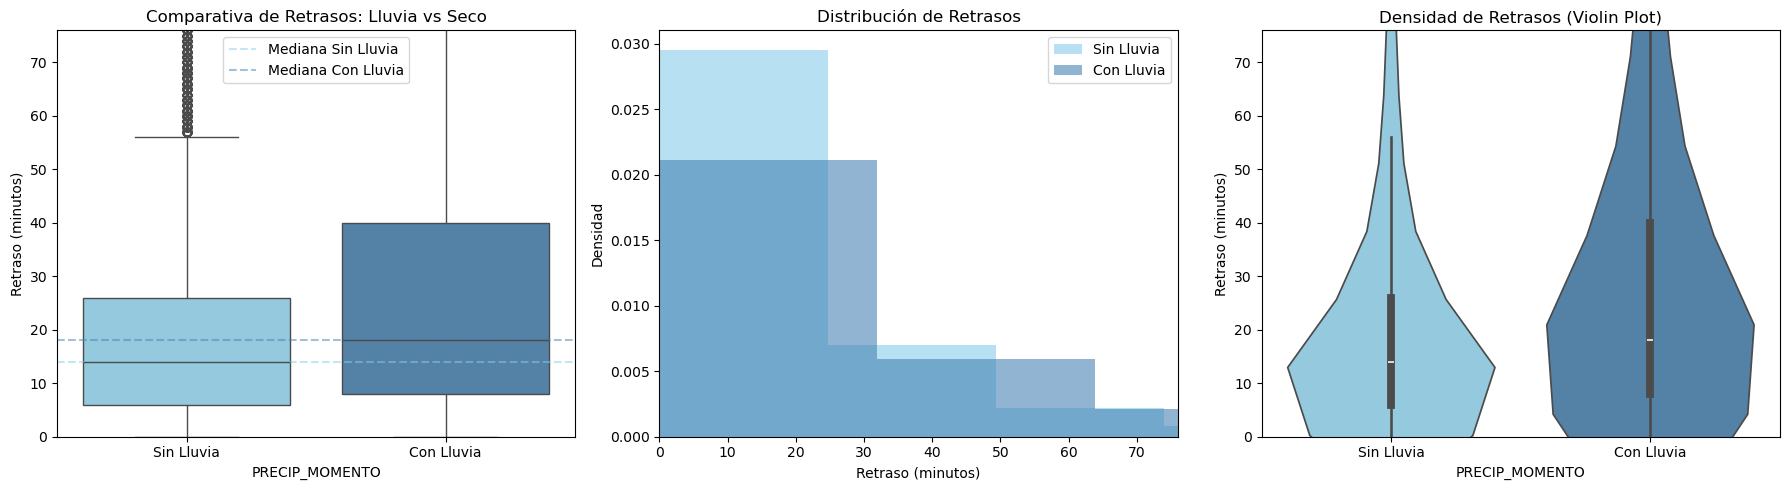

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot
es_lluvia = df['PRECIP_MOMENTO'] >= umbral_lluvia
sns.boxplot(
    x=es_lluvia, 
    y=df['RETRASO_MIN'], 
    hue=es_lluvia,
    ax=axes[0],
    palette=["skyblue", "steelblue"],
    legend=False
)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Sin Lluvia', 'Con Lluvia'])
axes[0].set_title('Comparativa de Retrasos: Lluvia vs Seco')
axes[0].set_ylabel('Retraso (minutos)')
# Limitar eje Y para ver mejor (eliminar outliers extremos)
axes[0].set_ylim(0, df['RETRASO_MIN'].quantile(0.95))
axes[0].axhline(grupo_seco.median(), color='skyblue', linestyle='--', alpha=0.5, label='Mediana Sin Lluvia')
axes[0].axhline(grupo_lluvia.median(), color='steelblue', linestyle='--', alpha=0.5, label='Mediana Con Lluvia')
axes[0].legend()

# Histograma
axes[1].hist(grupo_seco, bins=50, alpha=0.6, label='Sin Lluvia', color='skyblue', density=True)
axes[1].hist(grupo_lluvia, bins=50, alpha=0.6, label='Con Lluvia', color='steelblue', density=True)
axes[1].set_xlabel('Retraso (minutos)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de Retrasos')
axes[1].legend()
axes[1].set_xlim(0, df['RETRASO_MIN'].quantile(0.95))

# Violin plot
sns.violinplot(
    x=es_lluvia,
    y=df['RETRASO_MIN'],
    hue=es_lluvia,
    ax=axes[2],
    palette=["skyblue", "steelblue"],
    legend=False
)
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Sin Lluvia', 'Con Lluvia'])
axes[2].set_title('Densidad de Retrasos (Violin Plot)')
axes[2].set_ylabel('Retraso (minutos)')
axes[2].set_ylim(0, df['RETRASO_MIN'].quantile(0.95))

plt.tight_layout()
plt.show()